<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/April2026/6aprilConvNeXt_tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
train_dir = "/content/drive/MyDrive/ResearchData/April26/5Classes/TrainvsTestDataset1140images/train"
val_dir = "/content/drive/MyDrive/ResearchData/April26/5Classes/TrainvsTestDataset1140images/val"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

NUM_CLASSES = len(train_dataset.classes)

In [16]:
def train_eval(model, train_loader, val_loader, epochs=10):
    optimizer = optim.AdamW(model.parameters(), lr=3e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                outputs = model(images)
                preds = torch.argmax(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        acc = accuracy_score(all_labels, all_preds)
        print(f"Epoch {epoch+1} Acc: {acc:.4f}")

    return acc

In [17]:
from torchvision.models import efficientnet_v2_s

def get_effnet():
    model = efficientnet_v2_s(pretrained=True)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    return model.to(device)

model_eff = get_effnet()

print("\n🔵 EfficientNetV2 Training")
acc_eff = train_eval(model_eff, train_loader, val_loader, epochs=10)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



🔵 EfficientNetV2 Training
Epoch 1 Acc: 0.6947
Epoch 2 Acc: 0.7124
Epoch 3 Acc: 0.7522
Epoch 4 Acc: 0.7478
Epoch 5 Acc: 0.7655
Epoch 6 Acc: 0.7478
Epoch 7 Acc: 0.7788
Epoch 8 Acc: 0.7257
Epoch 9 Acc: 0.7611
Epoch 10 Acc: 0.7655


In [22]:
def get_convnext():
    model = models.convnext_tiny(pretrained=True)
    model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
    return model.to(device)

model_conv = get_convnext()

print("\n🟢 ConvNeXt Training")
acc_conv = train_eval(model_conv, train_loader, val_loader, epochs=10)


🟢 ConvNeXt Training
Epoch 1 Acc: 0.6814
Epoch 2 Acc: 0.7168
Epoch 3 Acc: 0.6991
Epoch 4 Acc: 0.7832
Epoch 5 Acc: 0.7566
Epoch 6 Acc: 0.7168
Epoch 7 Acc: 0.7478
Epoch 8 Acc: 0.7080
Epoch 9 Acc: 0.7611
Epoch 10 Acc: 0.7788


In [23]:
class ConvNeXtEmbedding(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()

        base = models.convnext_tiny(pretrained=True)
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(768, embedding_dim)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [24]:
import torch.nn.functional as F

class ArcFace(nn.Module):
    def __init__(self, in_features, num_classes, s=30.0, m=0.5):
        super().__init__()
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, labels):
        x = F.normalize(x)
        W = F.normalize(self.weight)

        cosine = F.linear(x, W)

        theta = torch.acos(torch.clamp(cosine, -1+1e-7, 1-1e-7))
        target = torch.cos(theta + self.m)

        one_hot = F.one_hot(labels, num_classes=cosine.size(1)).float()

        logits = cosine * (1 - one_hot) + target * one_hot
        logits *= self.s

        return logits

In [25]:
def train_arcface(model, arcface, train_loader, val_loader, epochs=5):

    optimizer = optim.AdamW(
        list(model.parameters()) + list(arcface.parameters()), lr=1e-4
    )
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            emb = model(images)
            logits = arcface(emb, labels)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        # VALIDATION
        model.eval()
        all_preds, all_labels = [], []

        classifier = nn.Linear(256, NUM_CLASSES).to(device)

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                emb = model(images)
                logits = classifier(emb)

                preds = torch.argmax(logits, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        acc = accuracy_score(all_labels, all_preds)
        print(f"Epoch {epoch+1} ArcFace Acc: {acc:.4f}")

In [26]:
embed_model = ConvNeXtEmbedding().to(device)
arcface = ArcFace(256, NUM_CLASSES).to(device)

print("\n🔥 ArcFace Training")
train_arcface(embed_model, arcface, train_loader, val_loader, epochs=10)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



🔥 ArcFace Training
Epoch 1 ArcFace Acc: 0.2699
Epoch 2 ArcFace Acc: 0.0929
Epoch 3 ArcFace Acc: 0.4425
Epoch 4 ArcFace Acc: 0.1460
Epoch 5 ArcFace Acc: 0.0619
Epoch 6 ArcFace Acc: 0.2035
Epoch 7 ArcFace Acc: 0.2434
Epoch 8 ArcFace Acc: 0.0708
Epoch 9 ArcFace Acc: 0.1549
Epoch 10 ArcFace Acc: 0.2611


In [27]:
def plot_tsne(model, loader, num_samples=500):
    model.eval()

    features = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            emb = model(images)

            features.append(emb.cpu().numpy())
            labels_list.append(labels.numpy())

            if len(features)*32 > num_samples:
                break

    features = np.concatenate(features)
    labels_list = np.concatenate(labels_list)

    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(features)

    plt.figure(figsize=(8,6))
    plt.scatter(reduced[:,0], reduced[:,1], c=labels_list, cmap='tab10')
    plt.colorbar()
    plt.title("t-SNE Feature Visualization")
    plt.show()

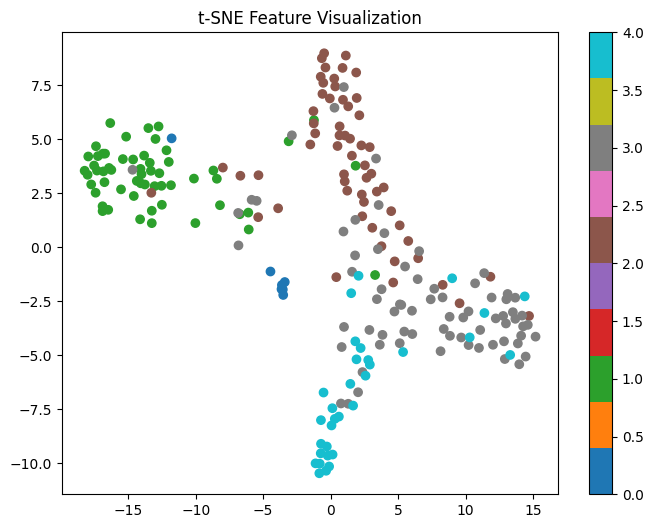

In [28]:
plot_tsne(embed_model, val_loader)

In [29]:
print("\n========== RESULTS ==========")
print(f"EfficientNetV2 : {acc_eff:.4f}")
print(f"ConvNeXt       : {acc_conv:.4f}")
print("ArcFace trained (see logs above)")


========== RESULTS ==========
EfficientNetV2 : 0.7655
ConvNeXt       : 0.7788
ArcFace trained (see logs above)
